In [1]:
# Cell 1 — Imports
import os
os.chdir(r'C:\Users\PC\financial-news-sentiment')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [2]:
# Cell 2 — Load model and vectorizer
lr = joblib.load('models/logistic_regression.pkl')
tfidf = joblib.load('models/tfidf_vectorizer.pkl')
le = joblib.load('models/label_encoder.pkl')

feature_names = np.array(tfidf.get_feature_names_out())
print(f"Classes: {le.classes_}")
print(f"Total features: {len(feature_names)}")

Classes: ['negative' 'neutral' 'positive']
Total features: 5000


In [3]:
# Cell 3 — Extract top words per class
def get_top_words(model, feature_names, class_index, n=15):
    coefs = model.coef_[class_index]
    top_positive_idx = np.argsort(coefs)[-n:][::-1]
    top_negative_idx = np.argsort(coefs)[:n]
    return (feature_names[top_positive_idx], coefs[top_positive_idx],
            feature_names[top_negative_idx], coefs[top_negative_idx])

for i, class_name in enumerate(le.classes_):
    top_words, top_coefs, bot_words, bot_coefs = get_top_words(lr, feature_names, i)
    print(f"\n=== {class_name.upper()} ===")
    print("Top predictive words:")
    for word, coef in zip(top_words, top_coefs):
        print(f"  {word}: {coef:.3f}")


=== NEGATIVE ===
Top predictive words:
  down: 4.051
  decreased: 3.641
  fell: 3.040
  cut: 2.337
  lower: 1.999
  staff: 1.994
  layoff: 1.973
  off: 1.797
  down from: 1.781
  result: 1.777
  loss: 1.775
  dropped: 1.713
  declined: 1.628
  negative: 1.592
  low: 1.576

=== NEUTRAL ===
Top predictive words:
  is: 1.956
  approximately: 1.577
  not: 1.166
  no: 1.144
  stake: 1.086
  development: 1.055
  business: 1.025
  include: 0.973
  includes: 0.961
  other: 0.948
  range: 0.944
  the order: 0.931
  sell: 0.864
  your: 0.830
  will: 0.829

=== POSITIVE ===
Top predictive words:
  increased: 2.588
  up: 2.582
  rose: 2.466
  increase: 2.459
  up from: 2.215
  grew: 2.097
  signed: 1.958
  order: 1.803
  rose to: 1.798
  leading: 1.732
  our: 1.652
  improved: 1.644
  positive: 1.623
  growth: 1.622
  agreement: 1.514


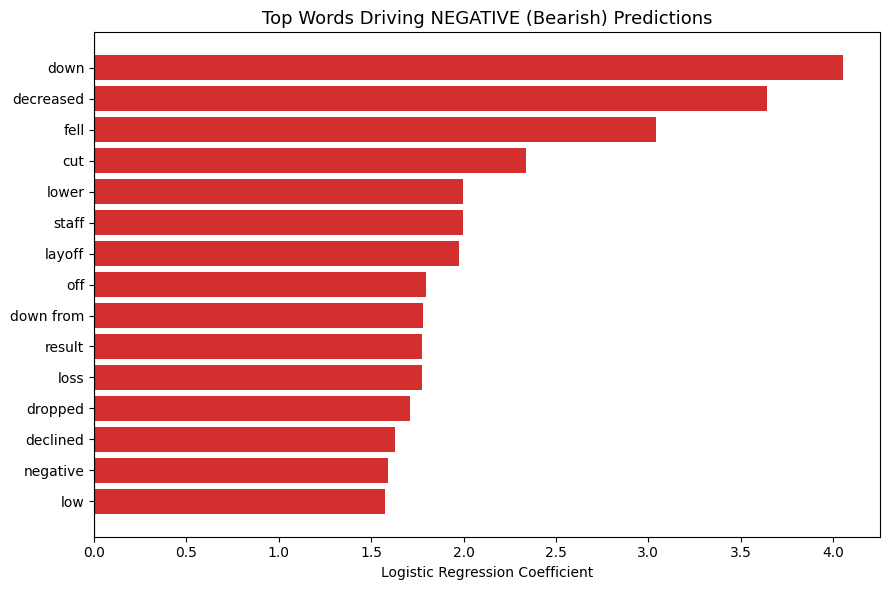

In [4]:
# Cell 4 — Visualize top words for NEGATIVE class (most business-critical)
fig, ax = plt.subplots(figsize=(9, 6))

top_words, top_coefs, _, _ = get_top_words(lr, feature_names, 
                                             list(le.classes_).index('negative'), n=15)

colors = ['#d32f2f' if c > 0 else '#1565c0' for c in top_coefs]
ax.barh(top_words[::-1], top_coefs[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top Words Driving NEGATIVE (Bearish) Predictions', fontsize=13)
ax.set_xlabel('Logistic Regression Coefficient')
plt.tight_layout()
plt.savefig('reports/top_words_negative.png', dpi=150)
plt.show()

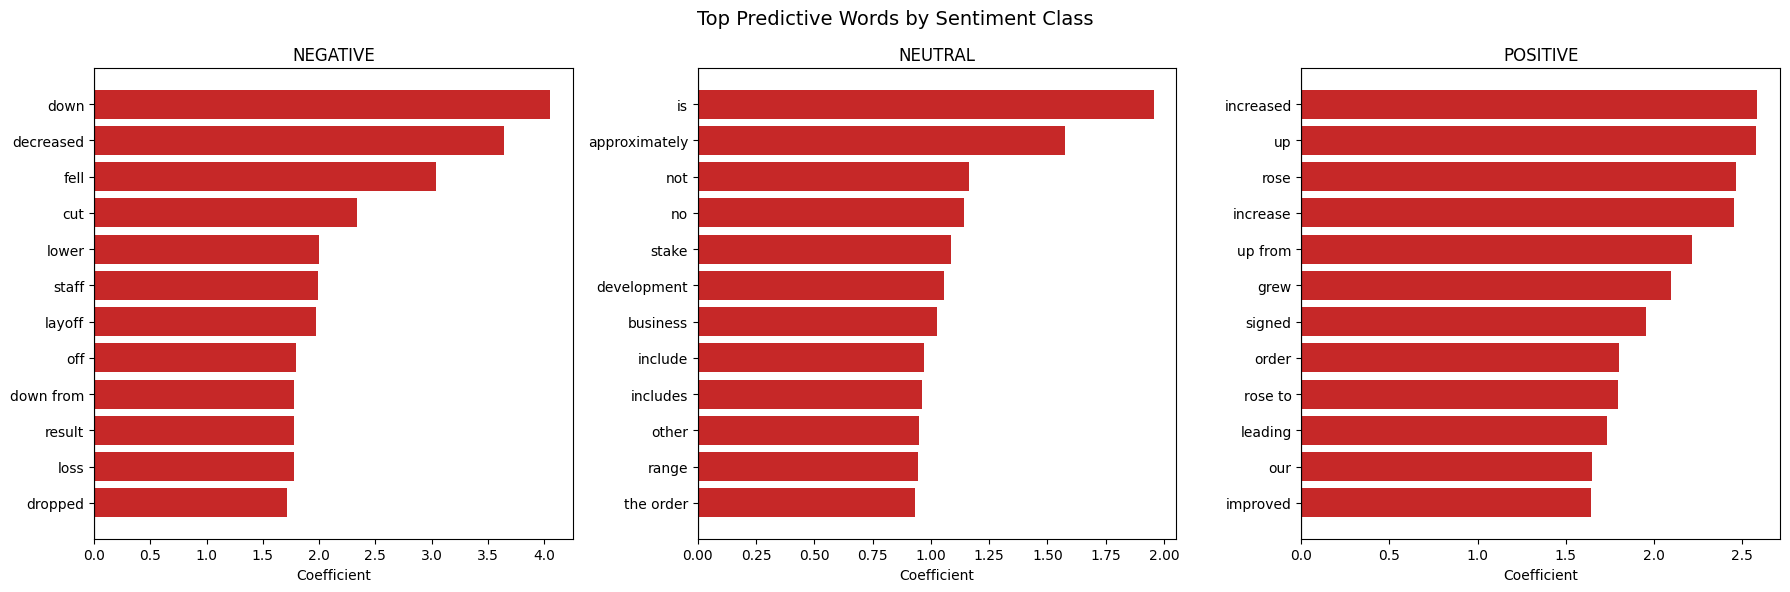

In [5]:
# Cell 5 — Visualize top words for all three classes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, class_name in enumerate(le.classes_):
    top_words, top_coefs, _, _ = get_top_words(lr, feature_names, i, n=12)
    colors = ['#c62828' if c > 0 else '#1565c0' for c in top_coefs]
    axes[i].barh(top_words[::-1], top_coefs[::-1], color=colors[::-1])
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'{class_name.upper()}', fontsize=12)
    axes[i].set_xlabel('Coefficient')

plt.suptitle('Top Predictive Words by Sentiment Class', fontsize=14)
plt.tight_layout()
plt.savefig('reports/top_words_all_classes.png', dpi=150)
plt.show()

In [6]:
# Cell 6 — Single prediction explainer
def explain_prediction(text, model, vectorizer, label_encoder):
    cleaned = text.lower()
    vec = vectorizer.transform([cleaned])
    pred_enc = model.predict(vec)[0]
    pred_proba = model.predict_proba(vec)[0]
    pred_label = label_encoder.inverse_transform([pred_enc])[0]
    
    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = model.coef_[pred_enc]
    vec_array = vec.toarray()[0]
    
    word_contributions = [(feature_names[i], coefs[i] * vec_array[i]) 
                         for i in np.where(vec_array > 0)[0]]
    word_contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    
    print(f"Text: {text}")
    print(f"Prediction: {pred_label.upper()}")
    print(f"Probabilities: {dict(zip(label_encoder.classes_, pred_proba.round(3)))}")
    print(f"\nTop contributing words:")
    for word, contrib in word_contributions[:8]:
        direction = "▲" if contrib > 0 else "▼"
        print(f"  {direction} {word}: {contrib:.4f}")

# Test on sample headlines
headlines = [
    "Company reports record losses and massive layoffs expected",
    "Strong quarterly earnings beat analyst expectations significantly",
    "The company maintained its market position during the period"
]

for h in headlines:
    print("\n" + "="*60)
    explain_prediction(h, lr, tfidf, le)


Text: Company reports record losses and massive layoffs expected
Prediction: NEUTRAL
Probabilities: {'negative': np.float64(0.091), 'neutral': np.float64(0.485), 'positive': np.float64(0.423)}

Top contributing words:
  ▼ record: -0.1983
  ▲ and: 0.1540
  ▼ expected: -0.1005
  ▲ company: 0.0400

Text: Strong quarterly earnings beat analyst expectations significantly
Prediction: POSITIVE
Probabilities: {'negative': np.float64(0.196), 'neutral': np.float64(0.213), 'positive': np.float64(0.591)}

Top contributing words:
  ▲ strong: 0.6175
  ▼ analyst: -0.2816
  ▲ significantly: 0.2706
  ▲ earnings: 0.1211
  ▲ quarterly: 0.1128

Text: The company maintained its market position during the period
Prediction: NEUTRAL
Probabilities: {'negative': np.float64(0.155), 'neutral': np.float64(0.464), 'positive': np.float64(0.381)}

Top contributing words:
  ▼ period: -0.2541
  ▲ market: 0.0908
  ▼ market position: -0.0740
  ▼ during the: -0.0625
  ▲ company: 0.0233
  ▼ the period: -0.0210
  ▲ the: 0

In [7]:
# Cell 7 — Save explainability outputs note
summary = {
    'model': 'Logistic Regression',
    'explainability_method': 'Coefficient-based word importance',
    'business_value': 'Traders can inspect which words drove bearish/bullish classification',
    'top_negative_signal': 'See reports/top_words_negative.png',
    'all_classes': 'See reports/top_words_all_classes.png'
}

import json
with open('reports/explainability_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Explainability notebook complete.")

Explainability notebook complete.
